# Class-wise AUROC/AUPR correlation analysis

`analysis/result/adaptclip.csv`와 `analysis/result/winclip_2.csv`를 사용해 class를 관측치로 두고 image-level 성능과 pixel-level localization 성능의 상관관계를 분석합니다.

- `adaptclip.csv`의 `Avg` 행은 클래스가 아니므로 제외합니다.
- AUROC/AUPR가 0-100 스케일이면 자동으로 0-1 스케일로 변환합니다.
- `pixel_auroc`는 정상/이상 pixel ranking을 평가하지만 pixel-level class imbalance에서 localization quality를 과대평가할 수 있습니다.
- `p_aupr`은 anomaly pixel의 precision-recall trade-off에 더 민감하므로, 가능한 경우 primary pixel-level metric으로 함께 확인합니다.
- Pearson: 선형 상관관계, Spearman: 순위 기반 단조 상관관계입니다.
- 표본 수가 작으므로 p-value와 함께 bootstrap confidence interval도 같이 확인합니다.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.4f}".format)

RESULT_DIR_CANDIDATES = [Path("result"), Path("analysis/result")]
RESULT_DIR = next((p for p in RESULT_DIR_CANDIDATES if p.exists()), None)
if RESULT_DIR is None:
    raise FileNotFoundError("Could not find result directory. Tried: result, analysis/result")

ADAPTCLIP_PATH = RESULT_DIR / "adaptclip.csv"
WINCLIP_PATH = RESULT_DIR / "winclip_2.csv"

EXPORT_DIR = RESULT_DIR / "analysis_exports"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)


def save_csv(df: pd.DataFrame, filename: str) -> Path:
    path = EXPORT_DIR / filename
    df.to_csv(path, index=False, encoding="utf-8-sig")
    print(f"Saved: {path}")
    return path

## 1. Load and clean data

In [ ]:
PIXEL_METRICS = ["pixel_auroc", "p_aupr"]
BASE_COLUMNS = ["class", "image_auroc"]


def load_result(path: Path, model_name: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    required = {"class", "image_auroc", "pixel_auroc"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{path} is missing columns: {sorted(missing)}")

    available_metrics = [m for m in PIXEL_METRICS if m in df.columns]
    cols = BASE_COLUMNS + available_metrics
    df = df.loc[~df["class"].astype(str).str.lower().eq("avg"), cols].copy()
    df["model"] = model_name

    # Make files comparable: some result files use 0-100, others use 0-1.
    for col in ["image_auroc", *available_metrics]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        if df[col].max(skipna=True) > 1.5:
            df[col] = df[col] / 100.0

    return df.dropna(subset=["class", "image_auroc", "pixel_auroc"])


adapt = load_result(ADAPTCLIP_PATH, "AdaptCLIP")
win = load_result(WINCLIP_PATH, "WinCLIP")
df = pd.concat([adapt, win], ignore_index=True, sort=False)

common_classes = sorted(set(adapt["class"]) & set(win["class"]))
df_common = df[df["class"].isin(common_classes)].copy()
metric_availability = (
    df_common.groupby("model")[["image_auroc", *PIXEL_METRICS]]
    .apply(lambda g: g.notna().sum())
    .reset_index()
)
df_ad = df[:15]
df_win = df[15:]
df_ad
df_ad["value"] = df_ad["pixel_auroc"] - df["p_aupr"]
df_ad[df_ad["value"] > 0.65]
# print(f"AdaptCLIP classes: {adapt['class'].nunique()}")
# print(f"WinCLIP classes: {win['class'].nunique()}")
# print(f"Common classes: {len(common_classes)}")
# print("Metric availability by model (non-null class count):")
# save_csv(metric_availability, "metric_availability.csv")
# save_csv(df_common.sort_values(["model", "class"]), "common_class_metrics.csv")
# display(metric_availability)
# display(df_common.sort_values(["model", "class"]))


/var/folders/vf/d0gygbv5527dd2h9xypg_1zm0000gn/T/ipykernel_8432/955815104.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ad["value"] = df_ad["pixel_auroc"] - df["p_aupr"]


,class,image_auroc,pixel_auroc,p_aupr,model,value
4,grid,0.9890,0.9740,0.2750,AdaptCLIP,0.6990
6,leather,1.0000,0.9910,0.2790,AdaptCLIP,0.7120
9,screw,0.8590,0.9790,0.2880,AdaptCLIP,0.6910
11,toothbrush,0.8640,0.8770,0.1350,AdaptCLIP,0.7420


## 2. Correlation statistics

Class별 점수 쌍 `(image_auroc, pixel metric)`을 관측치로 사용합니다.

- `image_vs_pixel_auroc`: image-level detection 성능과 pixel AUROC의 관계입니다.
- `image_vs_p_aupr`: image-level detection 성능과 pixel AUPR의 관계입니다. Pixel anomaly가 희소한 경우 더 보수적인 localization 지표입니다.
- `pixel_auroc_vs_p_aupr`: AUROC가 높아도 AUPR이 낮은 현상이 있는지 확인합니다.

`n_classes`가 15로 작기 때문에 p-value 하나만으로 결론내리지 말고 CI, scatter plot, class-level outlier를 같이 확인합니다.


In [3]:
def fisher_ci(r: float, n: int, alpha: float = 0.05) -> tuple[float, float]:
    if n <= 3 or abs(r) >= 1:
        return (np.nan, np.nan)
    z = np.arctanh(r)
    se = 1 / np.sqrt(n - 3)
    zcrit = stats.norm.ppf(1 - alpha / 2)
    return tuple(np.tanh([z - zcrit * se, z + zcrit * se]))


def bootstrap_corr_ci(x, y, method="pearson", n_boot=10000, random_state=42):
    rng = np.random.default_rng(random_state)
    x = np.asarray(x)
    y = np.asarray(y)
    n = len(x)
    vals = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        # Resamples with no variation cannot produce a correlation.
        if np.unique(x[idx]).size < 2 or np.unique(y[idx]).size < 2:
            continue
        if method == "pearson":
            vals.append(stats.pearsonr(x[idx], y[idx]).statistic)
        elif method == "spearman":
            vals.append(stats.spearmanr(x[idx], y[idx]).statistic)
        else:
            raise ValueError(method)
    return np.nanpercentile(vals, [2.5, 97.5])


def correlation_rows(data: pd.DataFrame, x_col: str, y_col: str, label: str) -> list[dict]:
    rows = []
    for model, g in data.groupby("model", sort=True):
        g = g.dropna(subset=[x_col, y_col])
        if len(g) < 4:
            continue
        x = g[x_col].to_numpy()
        y = g[y_col].to_numpy()
        pearson = stats.pearsonr(x, y)
        spearman = stats.spearmanr(x, y)
        pearson_ci = fisher_ci(pearson.statistic, len(g))
        pearson_boot_ci = bootstrap_corr_ci(x, y, "pearson")
        spearman_boot_ci = bootstrap_corr_ci(x, y, "spearman")
        rows.append(
            {
                "comparison": label,
                "model": model,
                "x": x_col,
                "y": y_col,
                "n_classes": len(g),
                "pearson_r": pearson.statistic,
                "pearson_p": pearson.pvalue,
                "pearson_fisher_ci_low": pearson_ci[0],
                "pearson_fisher_ci_high": pearson_ci[1],
                "pearson_boot_ci_low": pearson_boot_ci[0],
                "pearson_boot_ci_high": pearson_boot_ci[1],
                "spearman_rho": spearman.statistic,
                "spearman_p": spearman.pvalue,
                "spearman_boot_ci_low": spearman_boot_ci[0],
                "spearman_boot_ci_high": spearman_boot_ci[1],
            }
        )
    return rows


comparisons = [
    ("image_auroc", "pixel_auroc", "image_vs_pixel_auroc"),
    ("image_auroc", "p_aupr", "image_vs_p_aupr"),
    ("pixel_auroc", "p_aupr", "pixel_auroc_vs_p_aupr"),
]

corr_table = pd.DataFrame(
    row
    for x_col, y_col, label in comparisons
    if x_col in df_common.columns and y_col in df_common.columns
    for row in correlation_rows(df_common, x_col, y_col, label)
)

save_csv(corr_table, "correlation_statistics.csv")
display(corr_table)


Saved: result/analysis_exports/correlation_statistics.csv


,comparison,model,x,y,n_classes,pearson_r,pearson_p,pearson_fisher_ci_low,pearson_fisher_ci_high,pearson_boot_ci_low,pearson_boot_ci_high,spearman_rho,spearman_p,spearman_boot_ci_low,spearman_boot_ci_high
0,image_vs_pixel_auroc,AdaptCLIP,image_auroc,pixel_auroc,15,0.5580,0.0307,0.0640,0.8323,0.1860,0.8560,0.5671,0.0275,-0.0019,0.8850
1,image_vs_pixel_auroc,WinCLIP,image_auroc,pixel_auroc,15,0.2652,0.3395,-0.2859,0.6844,-0.1621,0.7349,0.3821,0.1598,-0.1773,0.7617
2,image_vs_p_aupr,AdaptCLIP,image_auroc,p_aupr,13,0.5069,0.0771,-0.0612,0.8269,-0.0686,0.8451,0.4174,0.1559,-0.2269,0.8969
3,pixel_auroc_vs_p_aupr,AdaptCLIP,pixel_auroc,p_aupr,13,0.4858,0.0923,-0.0890,0.8179,-0.2146,0.8037,0.2934,0.3306,-0.4034,0.7829


## 3. Class-level table

`gap_p_aupr_minus_pixel_auroc = p_aupr - pixel_auroc`입니다. 큰 음수이면 pixel AUROC에 비해 AUPR이 낮아, AUROC가 localization 품질을 낙관적으로 보일 가능성이 큽니다.

`gap_pixel_minus_image = pixel_auroc - image_auroc`은 기존 비교를 유지하기 위한 보조 지표입니다.


In [4]:
class_table = df_common.copy()
class_table["gap_pixel_minus_image"] = class_table["pixel_auroc"] - class_table["image_auroc"]
class_table["image_rank"] = class_table.groupby("model")["image_auroc"].rank(ascending=False, method="min")
class_table["pixel_auroc_rank"] = class_table.groupby("model")["pixel_auroc"].rank(ascending=False, method="min")
class_table["rank_shift_pixel_auroc_minus_image"] = class_table["pixel_auroc_rank"] - class_table["image_rank"]

if "p_aupr" in class_table.columns:
    class_table["gap_p_aupr_minus_pixel_auroc"] = class_table["p_aupr"] - class_table["pixel_auroc"]
    class_table["p_aupr_rank"] = class_table.groupby("model")["p_aupr"].rank(ascending=False, method="min")
    class_table["rank_shift_p_aupr_minus_pixel_auroc"] = class_table["p_aupr_rank"] - class_table["pixel_auroc_rank"]

sort_cols = ["model", "gap_p_aupr_minus_pixel_auroc"] if "gap_p_aupr_minus_pixel_auroc" in class_table.columns else ["model", "gap_pixel_minus_image"]
class_table_sorted = class_table.sort_values(sort_cols, ascending=[True, True]).reset_index(drop=True)
save_csv(class_table_sorted, "class_level_table.csv")
display(class_table_sorted)


Saved: result/analysis_exports/class_level_table.csv


,class,image_auroc,pixel_auroc,p_aupr,model,gap_pixel_minus_image,image_rank,pixel_auroc_rank,rank_shift_pixel_auroc_minus_image,gap_p_aupr_minus_pixel_auroc,p_aupr_rank,rank_shift_p_aupr_minus_pixel_auroc
0,leather,1.0000,0.9910,0.2790,AdaptCLIP,-0.0090,1.0000,2.0000,1.0000,-0.7120,10.0000,8.0000
1,grid,0.9890,0.9740,0.2750,AdaptCLIP,-0.0150,5.0000,5.0000,0.0000,-0.6990,12.0000,7.0000
2,screw,0.8590,0.9790,0.2880,AdaptCLIP,0.1200,14.0000,3.0000,-11.0000,-0.6910,9.0000,6.0000
3,cable,0.8360,0.7660,0.1560,AdaptCLIP,-0.0700,15.0000,13.0000,-2.0000,-0.6100,13.0000,0.0000
4,capsule,0.9520,0.9580,0.3540,AdaptCLIP,0.0060,7.0000,7.0000,0.0000,-0.6040,7.0000,0.0000
5,pill,0.8680,0.8990,0.3310,AdaptCLIP,0.0310,12.0000,11.0000,-1.0000,-0.5680,8.0000,-3.0000
6,metal_nut,0.9370,0.7650,0.2760,AdaptCLIP,-0.1720,9.0000,14.0000,5.0000,-0.4890,11.0000,-3.0000
7,zipper,0.9930,0.9180,0.4440,AdaptCLIP,-0.0750,4.0000,10.0000,6.0000,-0.4740,6.0000,-4.0000
8,hazelnut,0.9480,0.9760,0.5100,AdaptCLIP,0.0280,8.0000,4.0000,-4.0000,-0.4660,5.0000,1.0000
9,wood,0.9870,0.9690,0.5750,AdaptCLIP,-0.0180,6.0000,6.0000,0.0000,-0.3940,4.0000,-2.0000


## 4. Visualization

Scatter plot은 correlation table의 수치를 눈으로 검증하기 위한 용도입니다. 특히 `p_aupr` plot에서 특정 클래스가 상관관계를 강하게 흔드는지 확인합니다.


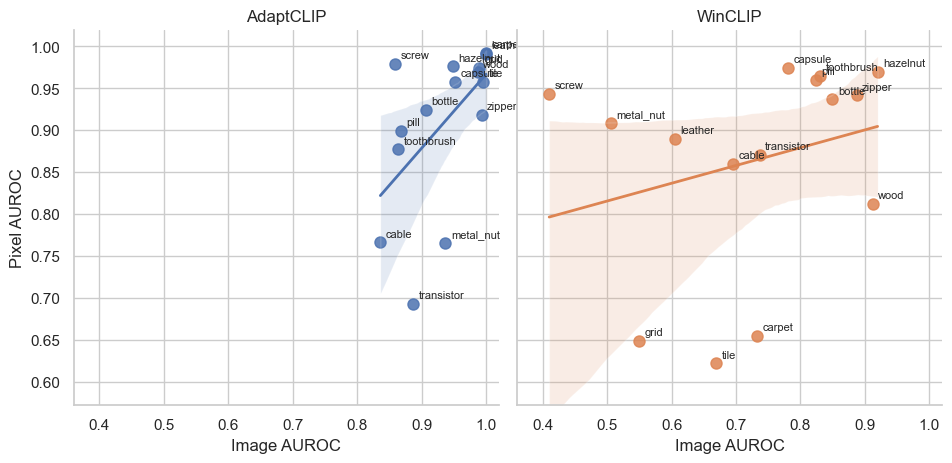

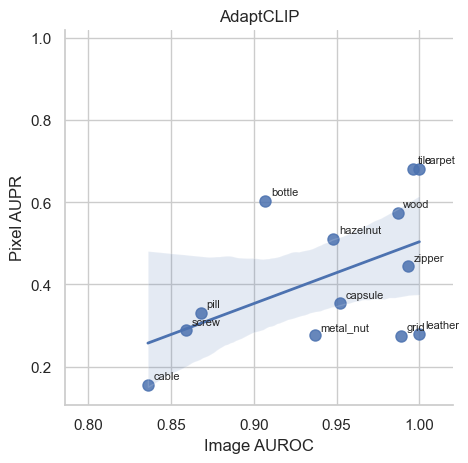

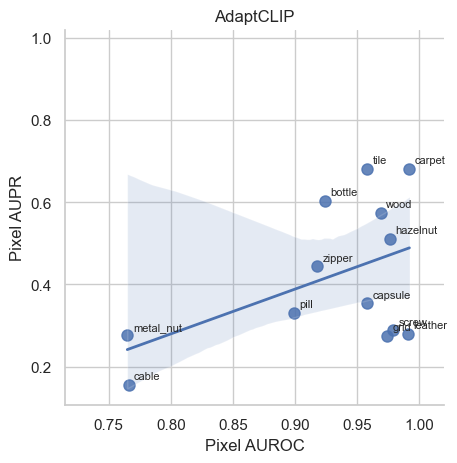

In [5]:
plot_specs = [
    ("image_auroc", "pixel_auroc", "Image AUROC", "Pixel AUROC"),
]
if "p_aupr" in df_common.columns and df_common["p_aupr"].notna().any():
    plot_specs.extend(
        [
            ("image_auroc", "p_aupr", "Image AUROC", "Pixel AUPR"),
            ("pixel_auroc", "p_aupr", "Pixel AUROC", "Pixel AUPR"),
        ]
    )

for x_col, y_col, x_label, y_label in plot_specs:
    plot_data = df_common.dropna(subset=[x_col, y_col])
    g = sns.lmplot(
        data=plot_data,
        x=x_col,
        y=y_col,
        hue="model",
        col="model",
        height=4.8,
        aspect=1,
        ci=95,
        scatter_kws={"s": 64, "alpha": 0.85},
        line_kws={"linewidth": 2},
    )
    g.set_axis_labels(x_label, y_label)
    g.set_titles("{col_name}")
    for ax, model in zip(g.axes.flat, sorted(plot_data["model"].unique())):
        sub = plot_data[plot_data["model"] == model]
        for _, row in sub.iterrows():
            ax.annotate(row["class"], (row[x_col], row[y_col]), xytext=(4, 4), textcoords="offset points", fontsize=8)
        ax.set_xlim(max(0, plot_data[x_col].min() - 0.05), 1.02)
        ax.set_ylim(max(0, plot_data[y_col].min() - 0.05), 1.02)
    plt.show()


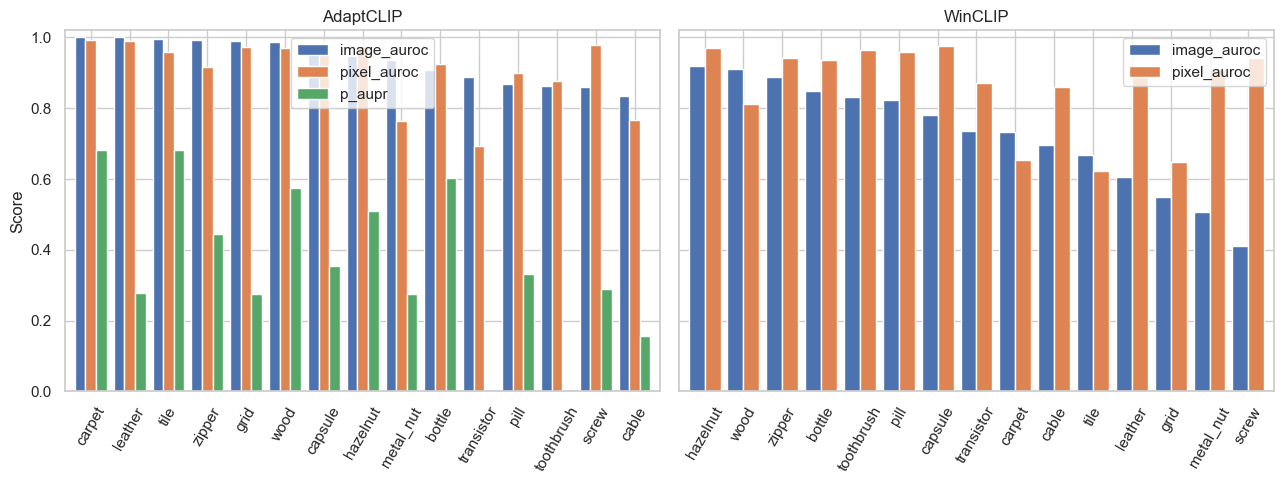

In [6]:
bar_metrics = ["image_auroc", "pixel_auroc"]
if "p_aupr" in df_common.columns and df_common["p_aupr"].notna().any():
    bar_metrics.append("p_aupr")

models = sorted(df_common["model"].unique())
fig, axes = plt.subplots(1, len(models), figsize=(6.5 * len(models), 5), sharey=True)
if len(models) == 1:
    axes = [axes]

for ax, model in zip(axes, models):
    pivot = (
        df_common[df_common["model"] == model]
        .set_index("class")[bar_metrics]
        .dropna(axis=1, how="all")
        .sort_values("image_auroc", ascending=False)
    )
    pivot.plot(kind="bar", ax=ax, width=0.82)
    ax.set_title(model)
    ax.set_xlabel("")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.02)
    ax.tick_params(axis="x", labelrotation=60)
plt.tight_layout()
plt.show()


## 5. Optional: compare AdaptCLIP and WinCLIP by class

같은 class에서 모델 간 AUROC가 같이 움직이는지도 확인합니다. `p_aupr`은 현재 AdaptCLIP에만 있으므로 모델 간 비교에서는 자동으로 제외됩니다.


In [7]:
available_between_model_metrics = [
    metric
    for metric in ["image_auroc", "pixel_auroc", "p_aupr"]
    if metric in df_common.columns and df_common.groupby("model")[metric].apply(lambda s: s.notna().all()).sum() >= 2
]

wide = df_common.pivot(index="class", columns="model", values=available_between_model_metrics)
wide.columns = [f"{metric}_{model}" for metric, model in wide.columns]
wide = wide.reset_index()

between_model_rows = []
for metric in available_between_model_metrics:
    metric_cols = [c for c in wide.columns if c.startswith(f"{metric}_")]
    if len(metric_cols) != 2:
        continue
    pair = wide[metric_cols].dropna()
    if len(pair) < 4:
        continue
    x = pair[metric_cols[0]]
    y = pair[metric_cols[1]]
    pearson = stats.pearsonr(x, y)
    spearman = stats.spearmanr(x, y)
    between_model_rows.append(
        {
            "metric": metric,
            "n_classes": len(pair),
            "model_x": metric_cols[0].replace(f"{metric}_", ""),
            "model_y": metric_cols[1].replace(f"{metric}_", ""),
            "pearson_r": pearson.statistic,
            "pearson_p": pearson.pvalue,
            "spearman_rho": spearman.statistic,
            "spearman_p": spearman.pvalue,
        }
    )

between_model_corr_table = pd.DataFrame(between_model_rows)
save_csv(wide, "between_model_class_metrics.csv")
save_csv(between_model_corr_table, "between_model_correlations.csv")
display(wide)
display(between_model_corr_table)


Saved: result/analysis_exports/between_model_class_metrics.csv
Saved: result/analysis_exports/between_model_correlations.csv


,class,image_auroc_AdaptCLIP,image_auroc_WinCLIP,pixel_auroc_AdaptCLIP,pixel_auroc_WinCLIP
0,bottle,0.9070,0.8492,0.9240,0.9368
1,cable,0.8360,0.6960,0.7660,0.8594
2,capsule,0.9520,0.7802,0.9580,0.9746
3,carpet,1.0000,0.7331,0.9920,0.6542
4,grid,0.9890,0.5489,0.9740,0.6482
5,hazelnut,0.9480,0.9196,0.9760,0.9699
6,leather,1.0000,0.6050,0.9910,0.8895
7,metal_nut,0.9370,0.5059,0.7650,0.9082
8,pill,0.8680,0.8243,0.8990,0.9598
9,screw,0.8590,0.4101,0.9790,0.9430


,metric,n_classes,model_x,model_y,pearson_r,pearson_p,spearman_rho,spearman_p
0,image_auroc,15,AdaptCLIP,WinCLIP,0.0820,0.7714,0.0054,0.9849
1,pixel_auroc,15,AdaptCLIP,WinCLIP,-0.2187,0.4335,-0.1287,0.6476


## 6. Quick interpretation helper

- `p < 0.05`이면 일반적으로 통계적으로 유의한 상관으로 해석합니다.
- 단, 클래스 수가 15개로 작기 때문에 p-value만 보지 말고 CI 폭과 scatter plot을 같이 확인하세요.
- Pearson은 outlier에 민감합니다. Spearman 결과가 Pearson과 크게 다르면 몇몇 class가 선형 관계를 흔들고 있을 수 있습니다.
- `pixel_auroc`는 pixel imbalance 상황에서 높게 유지될 수 있으므로 localization quality의 primary evidence로는 `p_aupr`을 함께 제시하는 편이 더 객관적입니다.
- `pixel_auroc`는 높지만 `p_aupr`이 낮은 class는 “ranking은 되지만 anomaly region을 정밀하게 분리하지 못한” 사례로 해석할 수 있습니다.
